In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

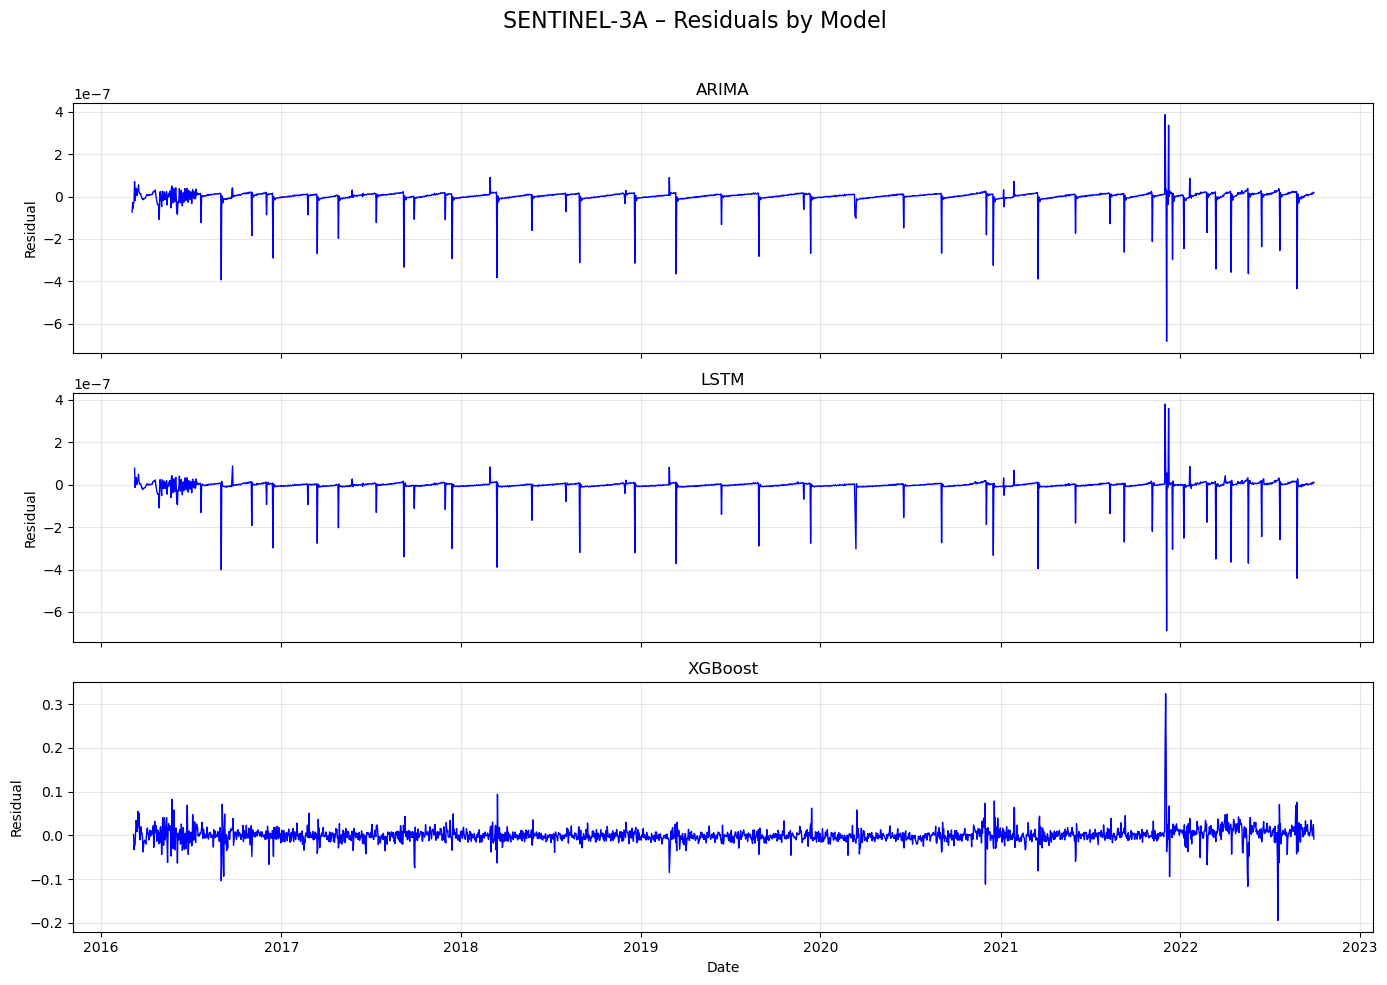

In [ ]:

# Load s3a data
s3a_models = {
    "ARIMA": pd.read_csv("result/s3a_arima_residuals.csv", parse_dates=["date"]),
    "LSTM": pd.read_csv("result/s3a_lstm_residuals.csv", parse_dates=["date"]),
    "XGBoost": pd.read_csv("result/s3a_xgb_residuals.csv", parse_dates=["date"])
}

# Plotting function
def plot_residuals_by_model(sat_name, models_dict, k=2):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{sat_name.upper()} – Residuals by Model", fontsize=16)

    for ax, (model_name, df) in zip(axes, models_dict.items()):
        df = df.sort_values("date")
        threshold = k * np.std(df["residual"])
        ax.plot(df["date"], df["residual"], label="Residual", color='blue', linewidth=1)
        ax.set_ylabel("Residual")
        ax.set_title(model_name)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Date")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Run for Sentinel-3A
plot_residuals_by_model("Sentinel-3A", s3a_models, k=2)


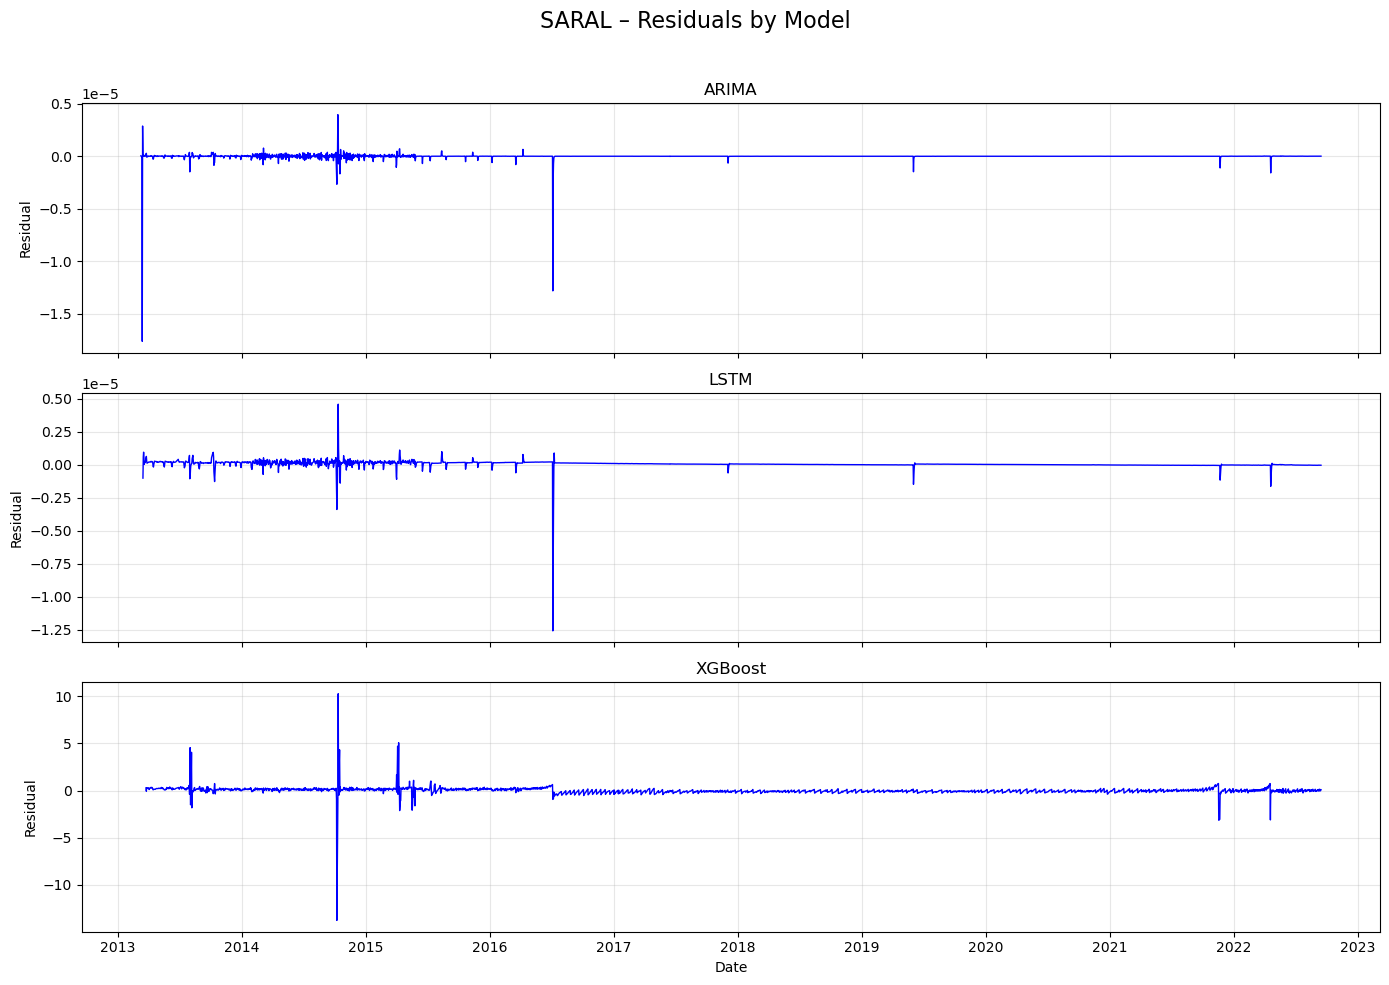

In [114]:
# Load SARAL data
saral_models = {
    "ARIMA": pd.read_csv("result/saral_arima_residuals.csv", parse_dates=["date"]),
    "LSTM": pd.read_csv("result/saral_lstm_residuals.csv", parse_dates=["date"]),
    "XGBoost": pd.read_csv("result/saral_xgb_residuals.csv", parse_dates=["date"])
}

# Plot SARAL residuals
plot_residuals_by_model("SARAL", saral_models, k=2)

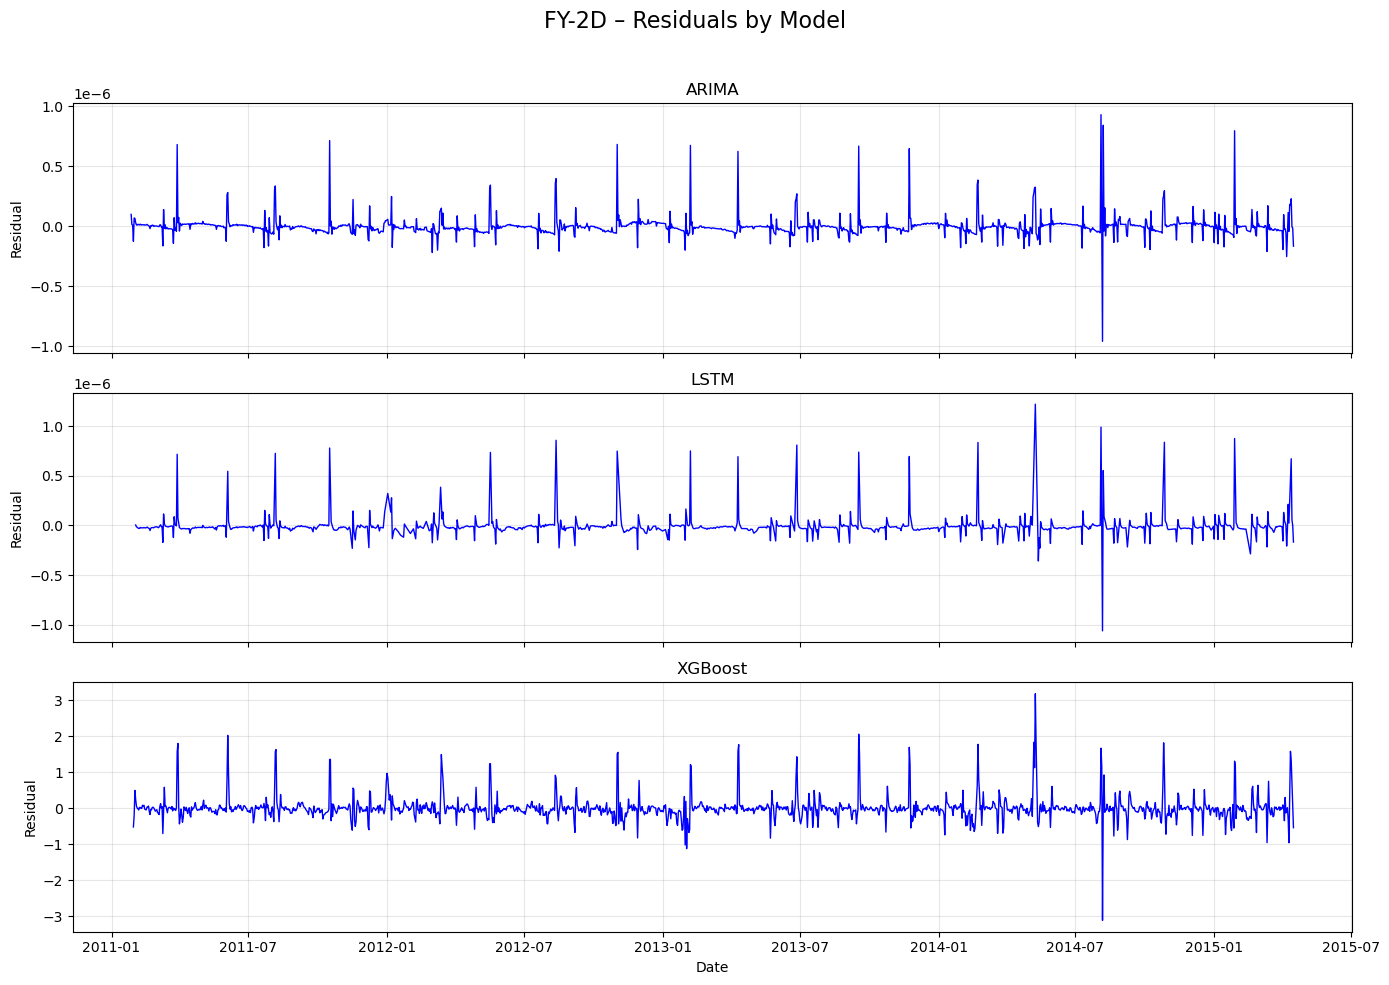

In [115]:
# Load FY-2D data
fy2d_models = {
    "ARIMA": pd.read_csv("result/fy2d_arima_residuals.csv", parse_dates=["date"]),
    "LSTM": pd.read_csv("result/fy2d_lstm_residuals.csv", parse_dates=["date"]),
    "XGBoost": pd.read_csv("result/fy2d_xgb_residuals.csv", parse_dates=["date"])
}

# Plot FY-2D residuals
plot_residuals_by_model("FY-2D", fy2d_models, k=2)

In [116]:
import scipy.stats as stats
import matplotlib.pyplot as plt

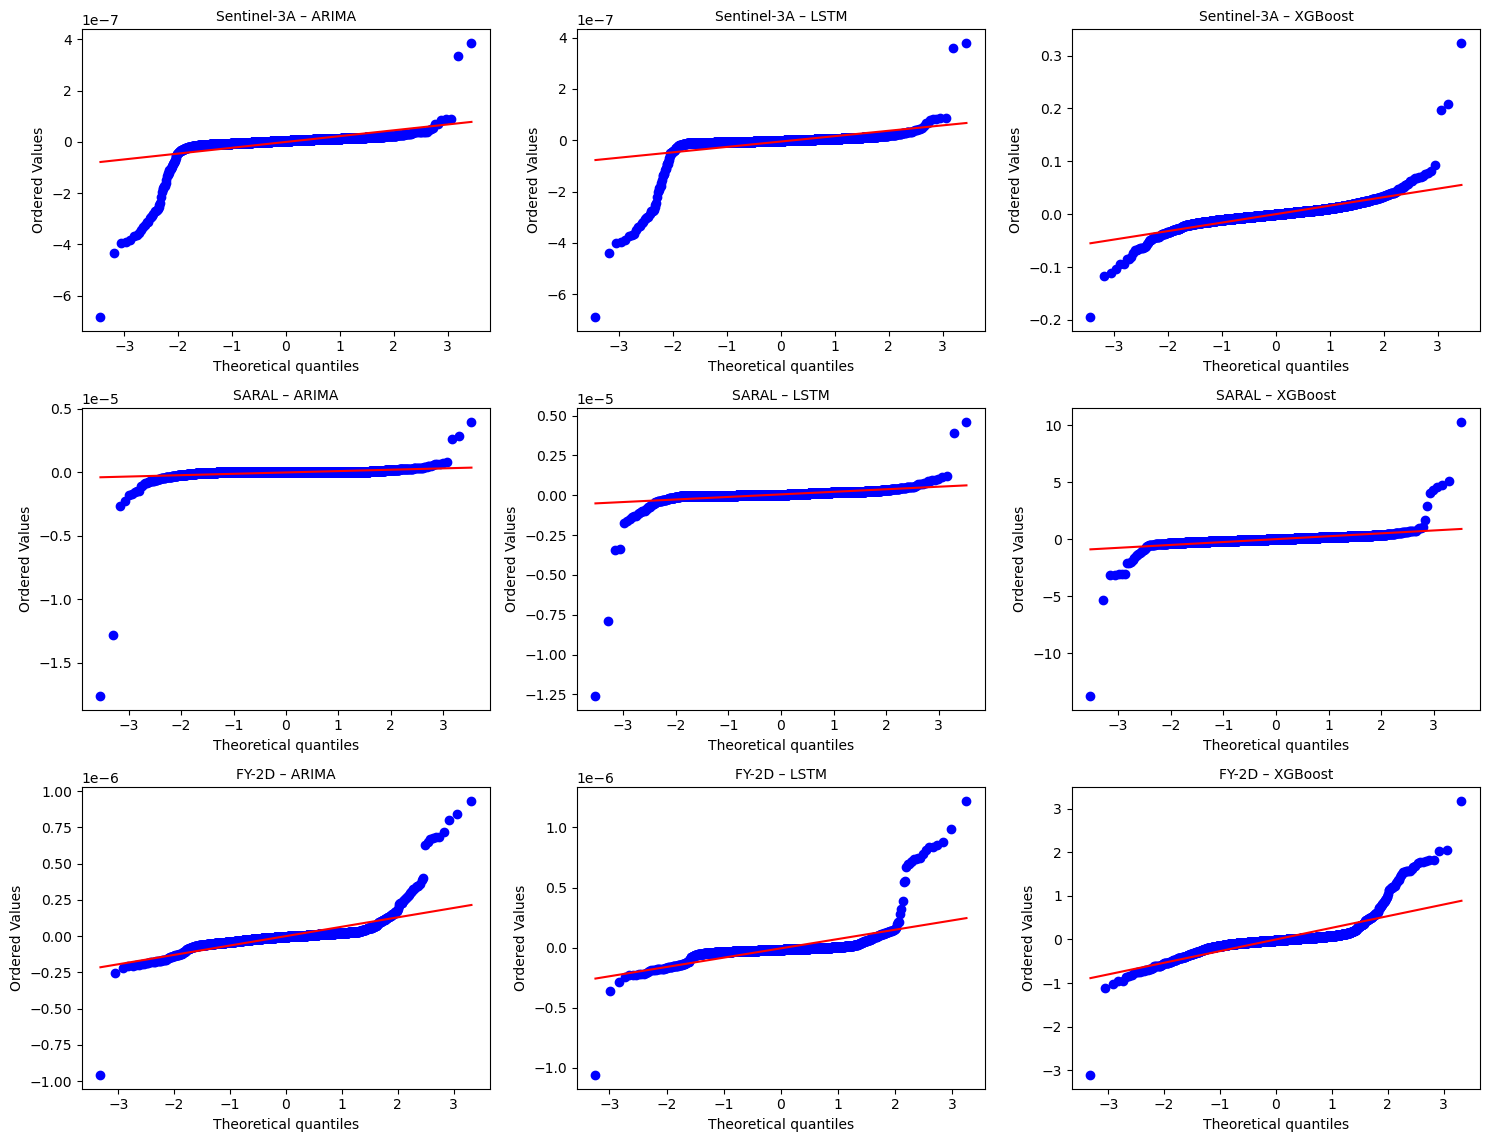

In [117]:
# Combine all model data into a single structure
all_models = {
    "Sentinel-3A": s3a_models,
    "SARAL": saral_models,
    "FY-2D": fy2d_models
}

# Set up 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Iterate through satellites and models
for i, (sat_name, models_dict) in enumerate(all_models.items()):
    for j, (model_name, df) in enumerate(models_dict.items()):
        ax = axes[i, j]
        stats.probplot(df["residual"], dist="norm", plot=ax)
        ax.get_lines()[1].set_color('red')  # Diagonal line
        ax.set_title(f"{sat_name} – {model_name}", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


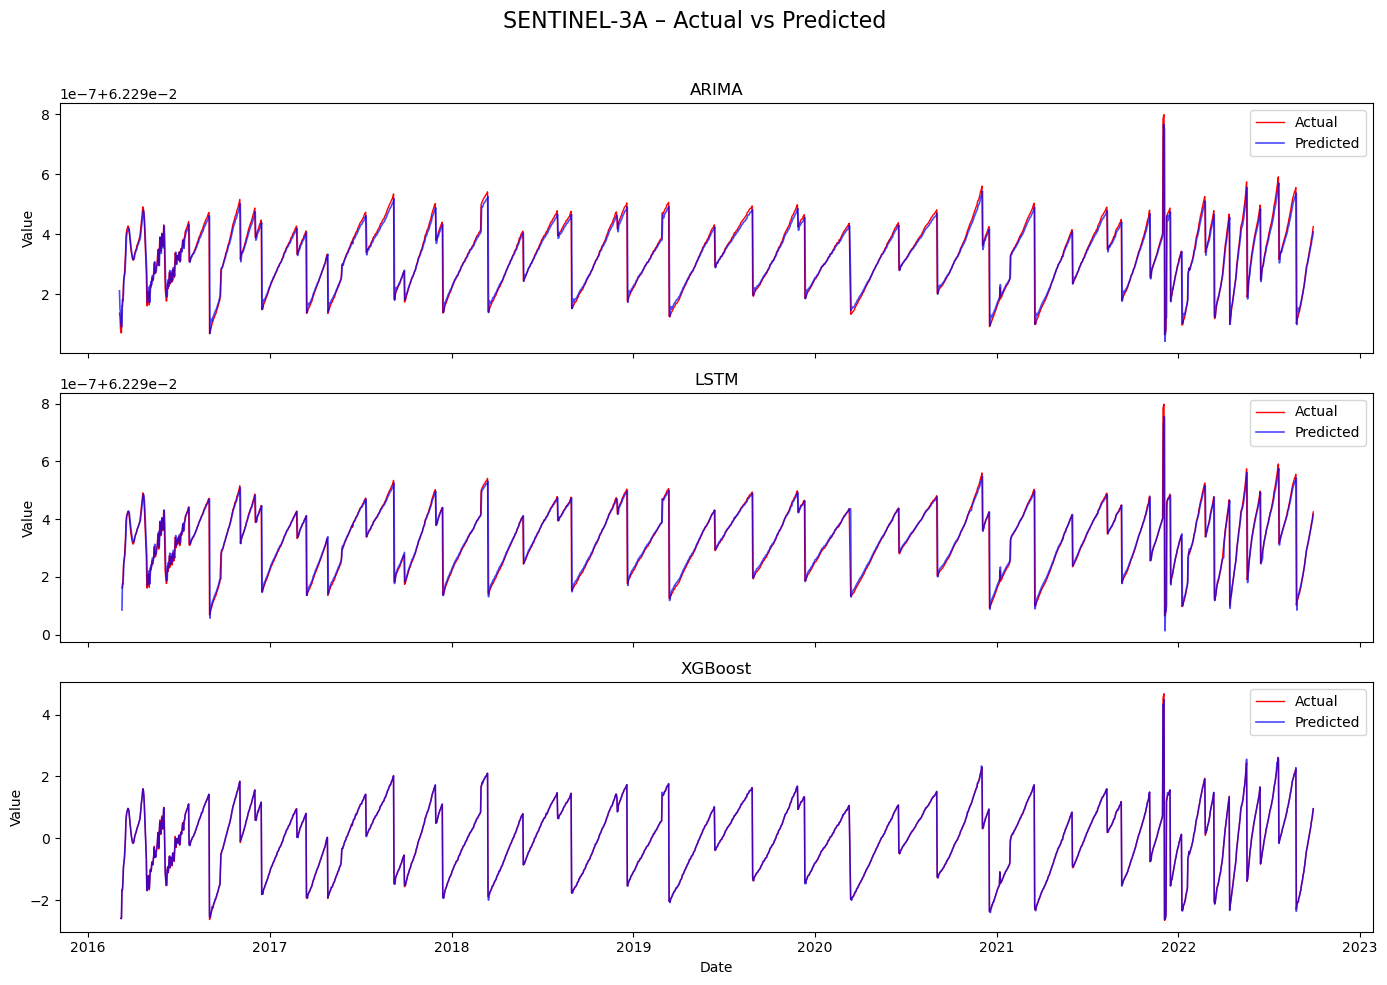

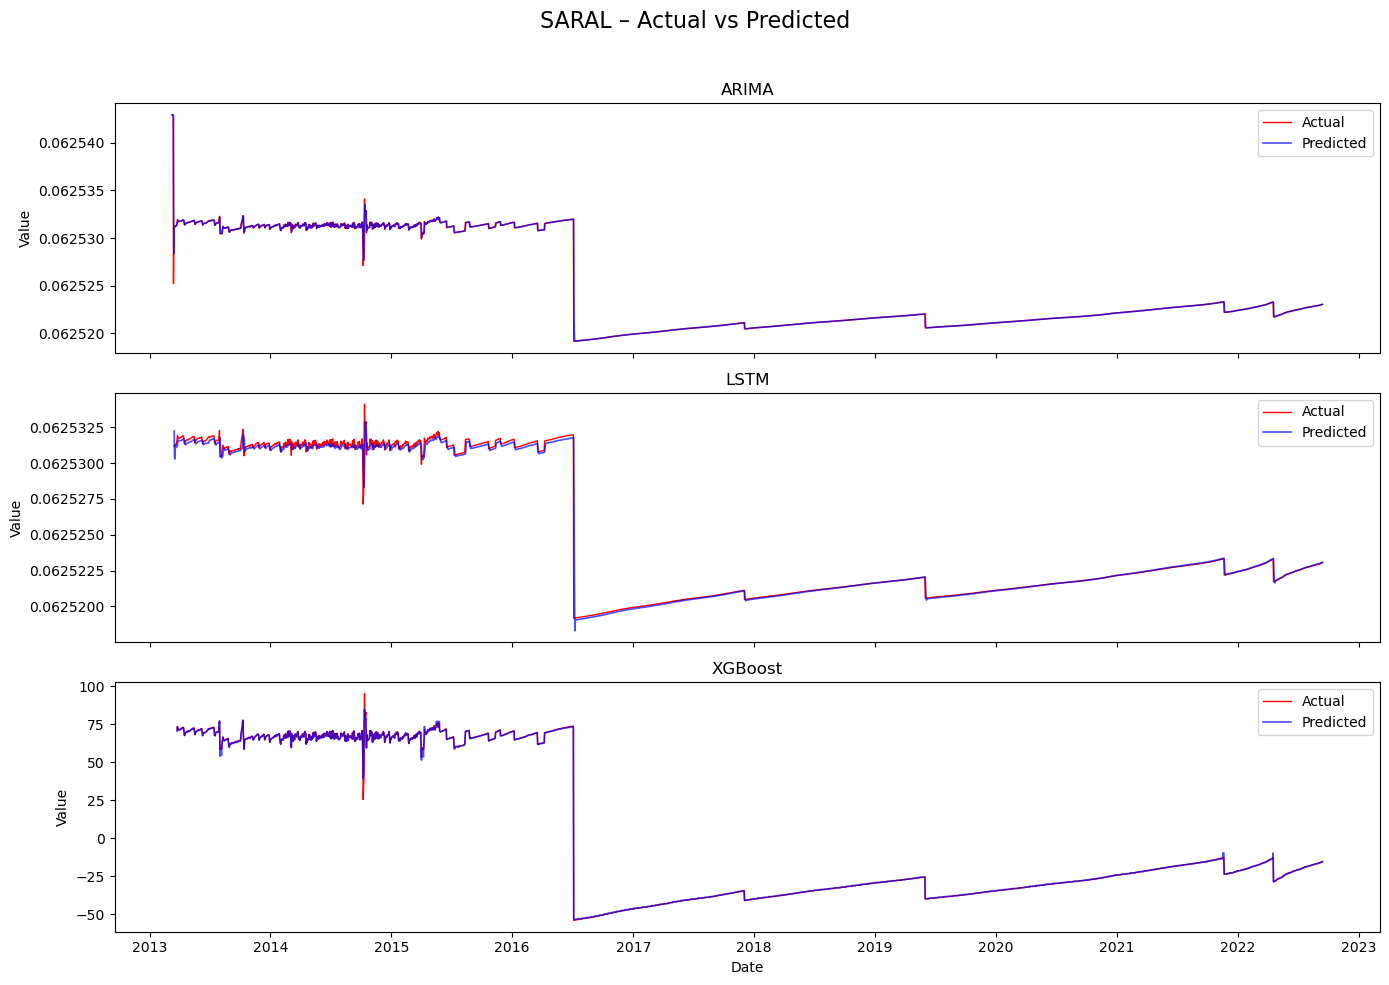

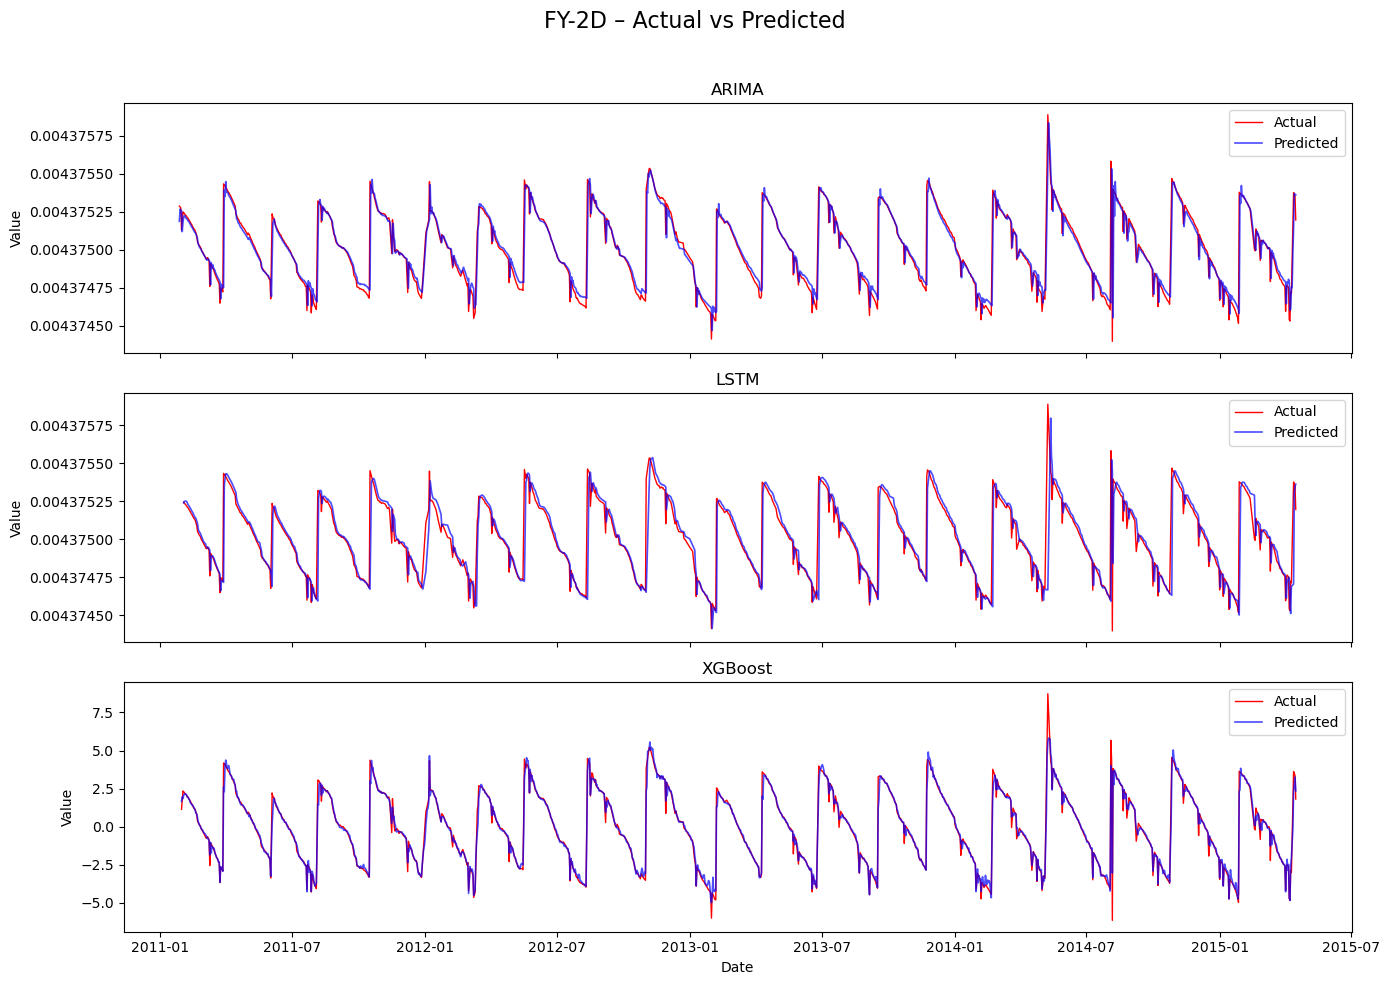

In [118]:
# Function to plot actual vs predicted for all models of one satellite
def plot_actual_vs_predicted(sat_name, models_dict):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{sat_name.upper()} – Actual vs Predicted", fontsize=16)

    for ax, (model_name, df) in zip(axes, models_dict.items()):
        df = df.sort_values("date")
        ax.plot(df["date"], df["actual"], label="Actual", color='red', linewidth=1)
        ax.plot(df["date"], df["pred"], label="Predicted", color='blue', linewidth=1.2, alpha=0.7)
        ax.set_ylabel("Value")
        ax.set_title(model_name)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Date")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Run for all three satellites
plot_actual_vs_predicted("Sentinel-3A", s3a_models)
plot_actual_vs_predicted("SARAL", saral_models)
plot_actual_vs_predicted("FY-2D", fy2d_models)


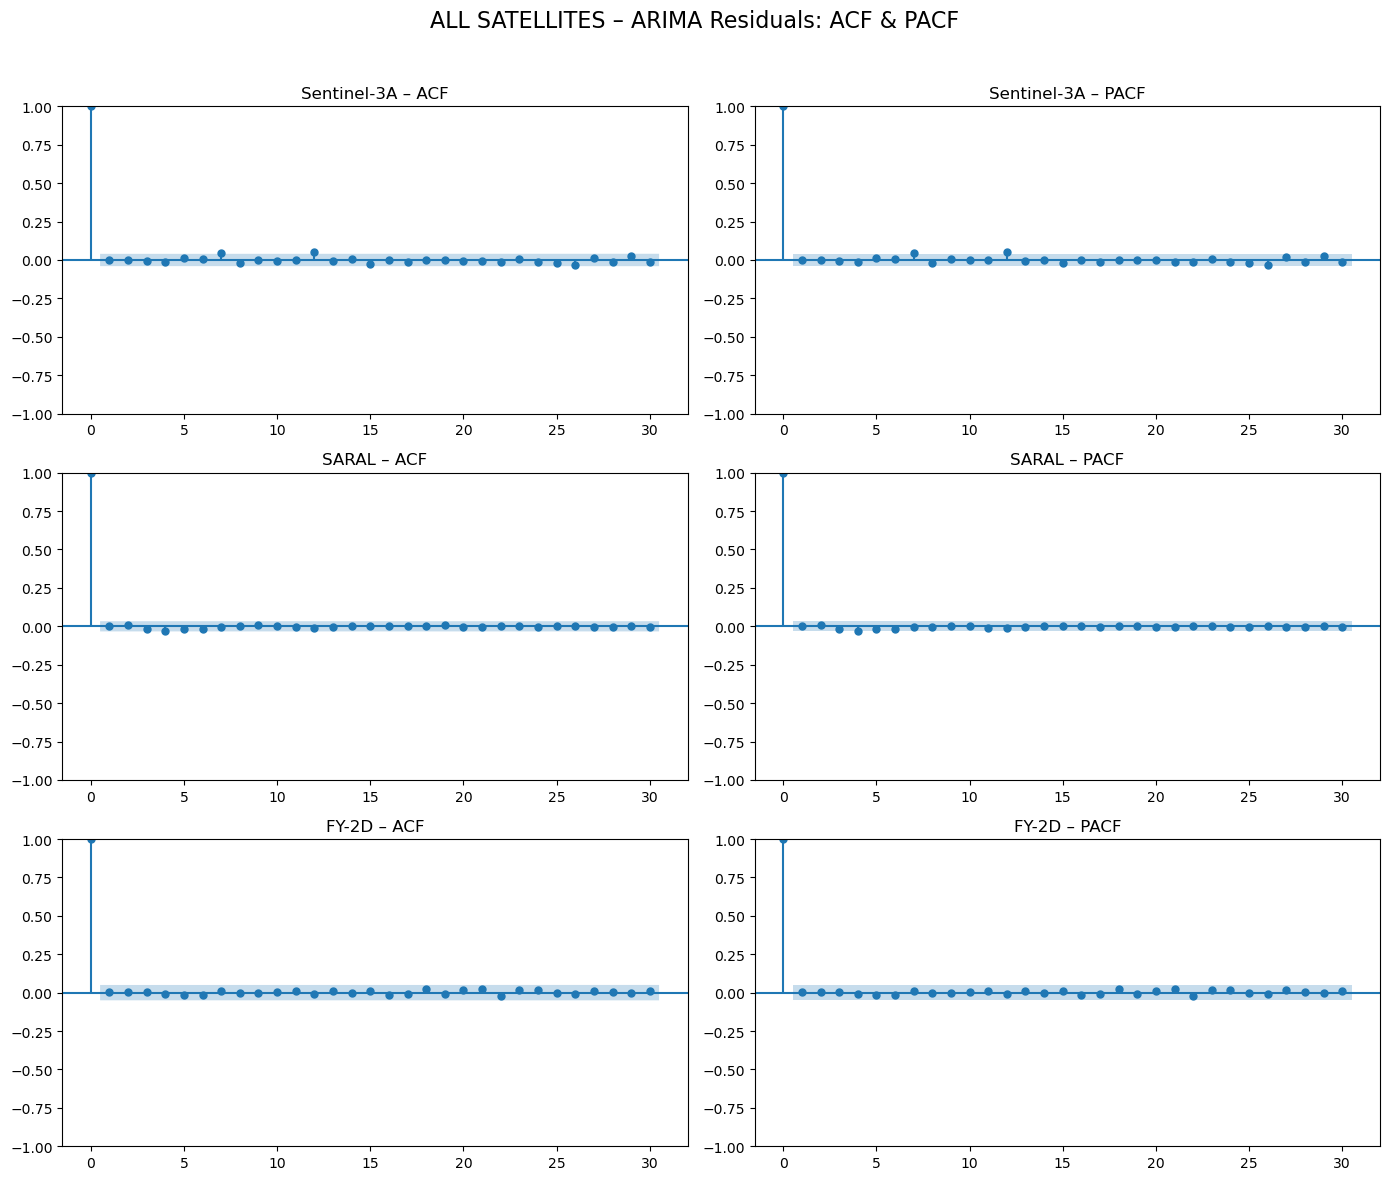

In [119]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Define plotting function for ACF & PACF (ARIMA only)
def plot_acf_pacf_grid(model_data, sat_name):
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(f"{sat_name.upper()} – ARIMA Residuals: ACF & PACF", fontsize=16)

    for i, (sat, models_dict) in enumerate(model_data.items()):
        df = models_dict["ARIMA"].sort_values("date")
        plot_acf(df["residual"], lags=30, ax=axes[i, 0])
        axes[i, 0].set_title(f"{sat} – ACF")

        plot_pacf(df["residual"], lags=30, ax=axes[i, 1])
        axes[i, 1].set_title(f"{sat} – PACF")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Collect only ARIMA models for all satellites
arima_models = {
    "Sentinel-3A": s3a_models,
    "SARAL": saral_models,
    "FY-2D": fy2d_models
}

plot_acf_pacf_grid(arima_models, "All Satellites")

In [120]:
import pickle

# Load maneuver data
with open("maneuvers.pkl", "rb") as f:
    maneuvers = pickle.load(f)

# Show available keys (satellites) and a preview of one
maneuver_keys = list(maneuvers.keys())
example_df = maneuvers[maneuver_keys[0]].head()

maneuver_keys, example_df

(['cs2',
  'h2a',
  'ja1',
  'ja2',
  'ja3',
  's3a',
  's3b',
  's6a',
  'srl',
  'FY2D',
  'FY2E',
  'FY2F',
  'FY2H',
  'FY4A',
  'TOP'],
   Satellite      begin_day_time        end_day_time     median_day_time
 0     CRYO2 2010-04-15 17:47:00 2010-04-15 17:48:00 2010-04-15 17:47:30
 1     CRYO2 2010-05-03 17:55:00 2010-05-04 00:35:00 2010-05-03 21:15:00
 2     CRYO2 2010-05-04 18:38:00 2010-05-04 18:48:00 2010-05-04 18:43:00
 3     CRYO2 2010-05-05 17:44:00 2010-05-05 17:59:00 2010-05-05 17:51:30
 4     CRYO2 2010-05-06 18:26:00 2010-05-06 18:51:00 2010-05-06 18:38:30)

In [135]:
# Further reduce transparency of manoeuvre lines (alpha) and legend size
def plot_residuals_with_manoeuvres_and_anomalies_final(sat_name, models_dict, maneuver_df, k=2):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{sat_name.upper()} – Residuals with True Manoeuvres and Detected Anomalies", fontsize=16)

    # Normalize maneuver dates
    man_dates = pd.to_datetime(maneuver_df["median_day_time"]).dt.normalize().unique()

    for ax, (model_name, df) in zip(axes, models_dict.items()):
        df = df.sort_values("date")
        df["abs_resid"] = df["residual"].abs()
        threshold = k * df["abs_resid"].std()

        # Plot residuals
        ax.plot(df["date"], df["residual"], label="Residual", color='blue', linewidth=1)

        # Plot true manoeuvres (deep gray, low alpha)
        for d in man_dates:
            ax.axvline(d, color="#444444", linestyle="--", alpha=0.3, label="True Manoeuvre" if d == man_dates[0] else None)

        # Plot detected anomalies (red dots)
        anomaly_dates = df.loc[df["abs_resid"] > threshold, "date"]
        ax.scatter(anomaly_dates, df.loc[df["abs_resid"] > threshold, "residual"],
                   color="red", s=15, label="Detected Anomaly", zorder=5)

        ax.set_ylabel("Residual")
        ax.set_title(model_name)
        ax.legend(loc="lower right", fontsize="small")  # Smaller legend text

    axes[-1].set_xlabel("Date")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

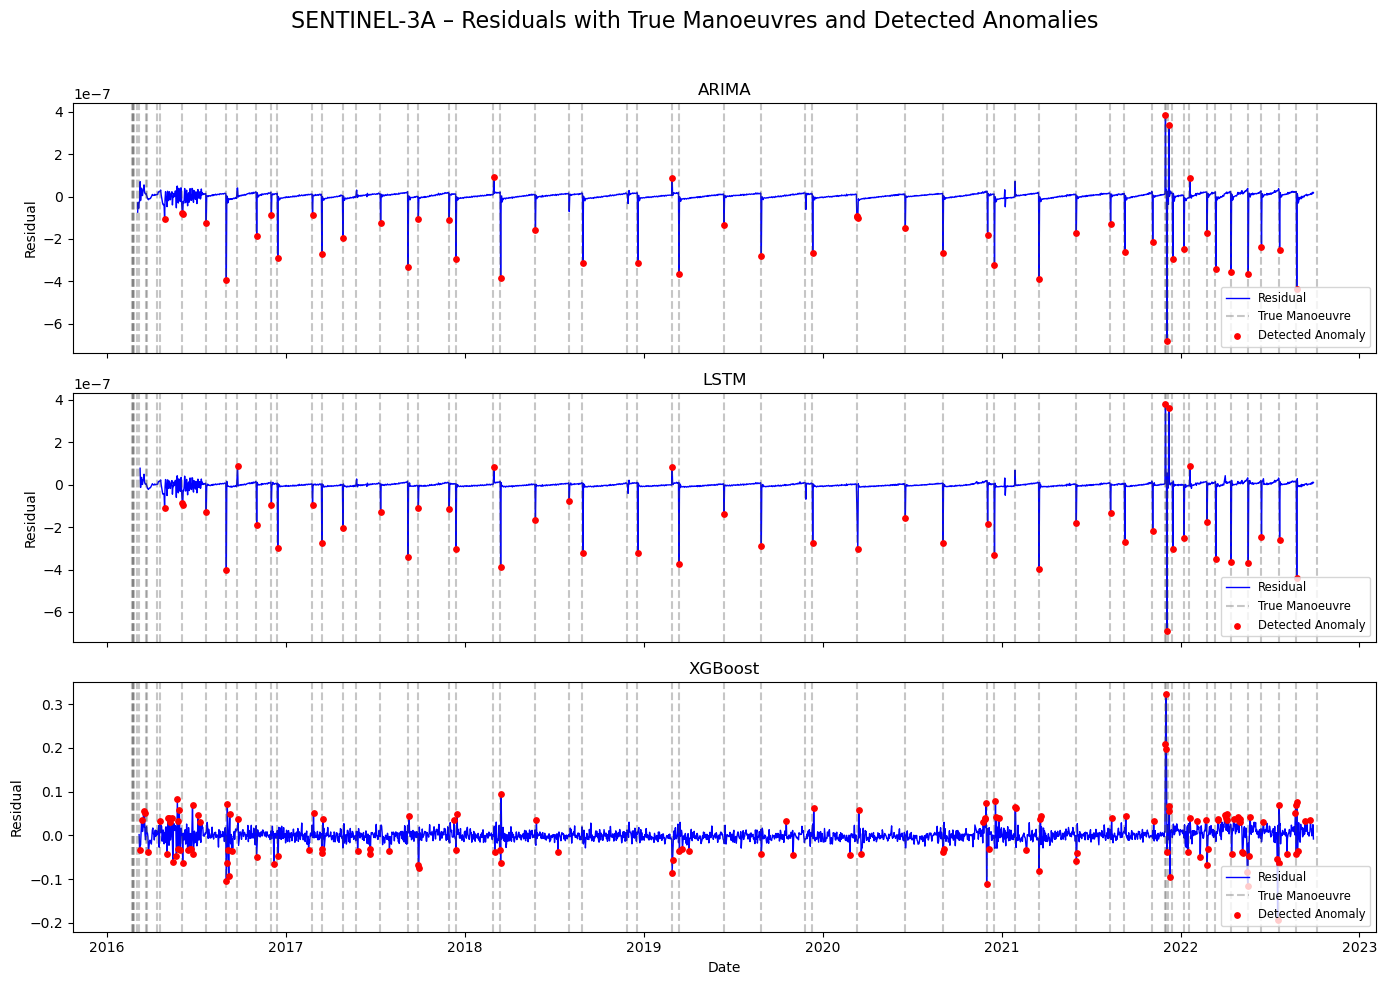

In [ ]:
# Apply updated plotting for Sentinel-3A
plot_residuals_with_manoeuvres_and_anomalies_final(
    sat_name="Sentinel-3A",
    models_dict=s3a_models,
    maneuver_df=maneuvers["s3a"],
    k=3
)

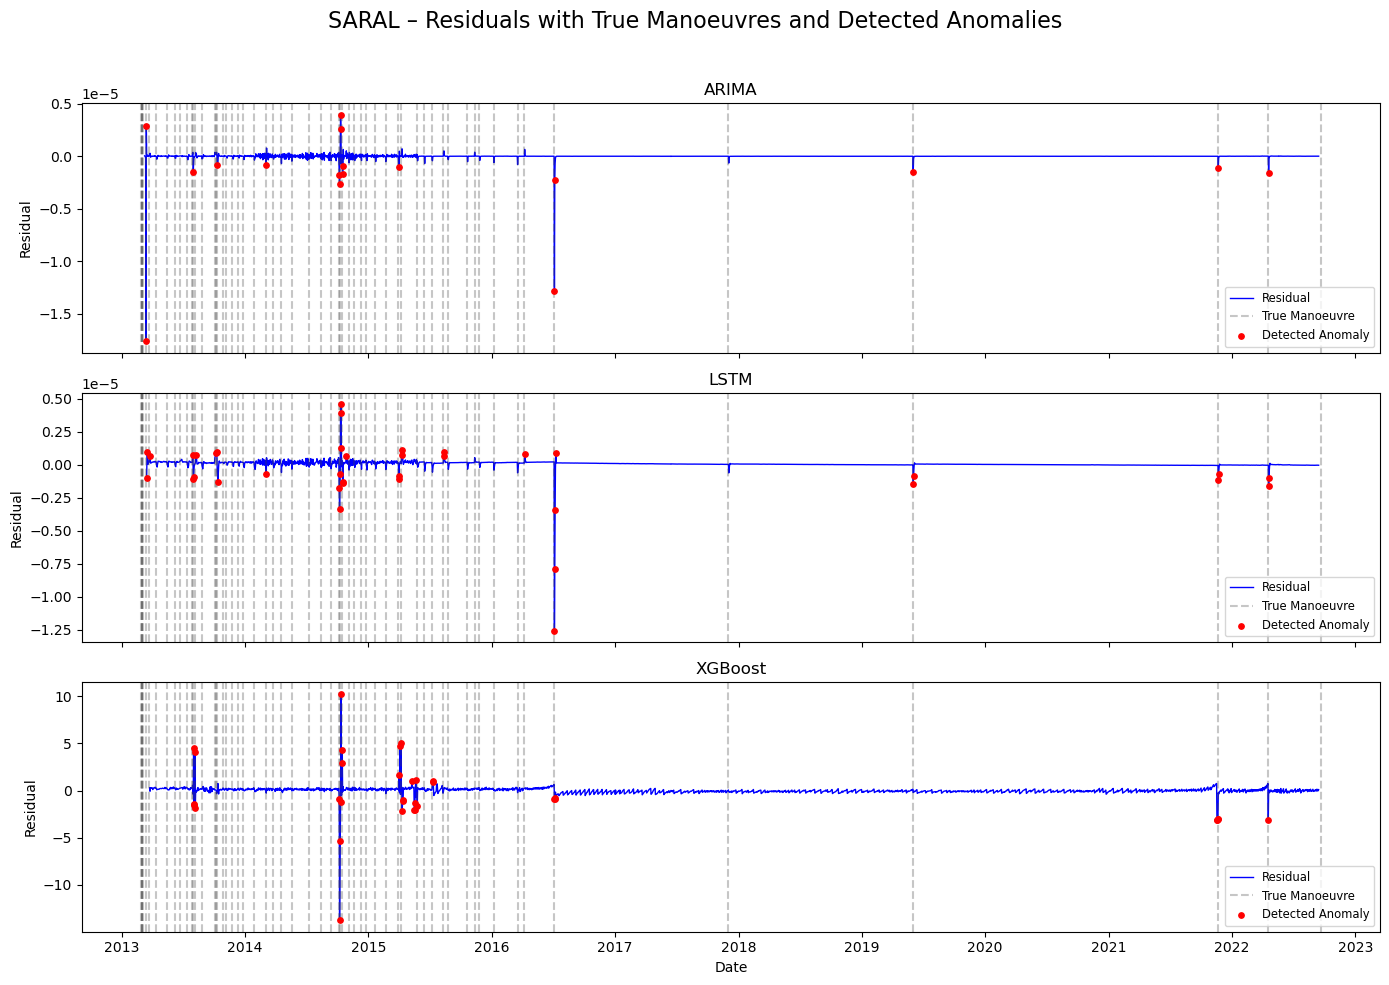

In [ ]:
# SARAL
plot_residuals_with_manoeuvres_and_anomalies_final(
    sat_name="SARAL",
    models_dict=saral_models,
    maneuver_df=maneuvers["srl"],
    k=3
)

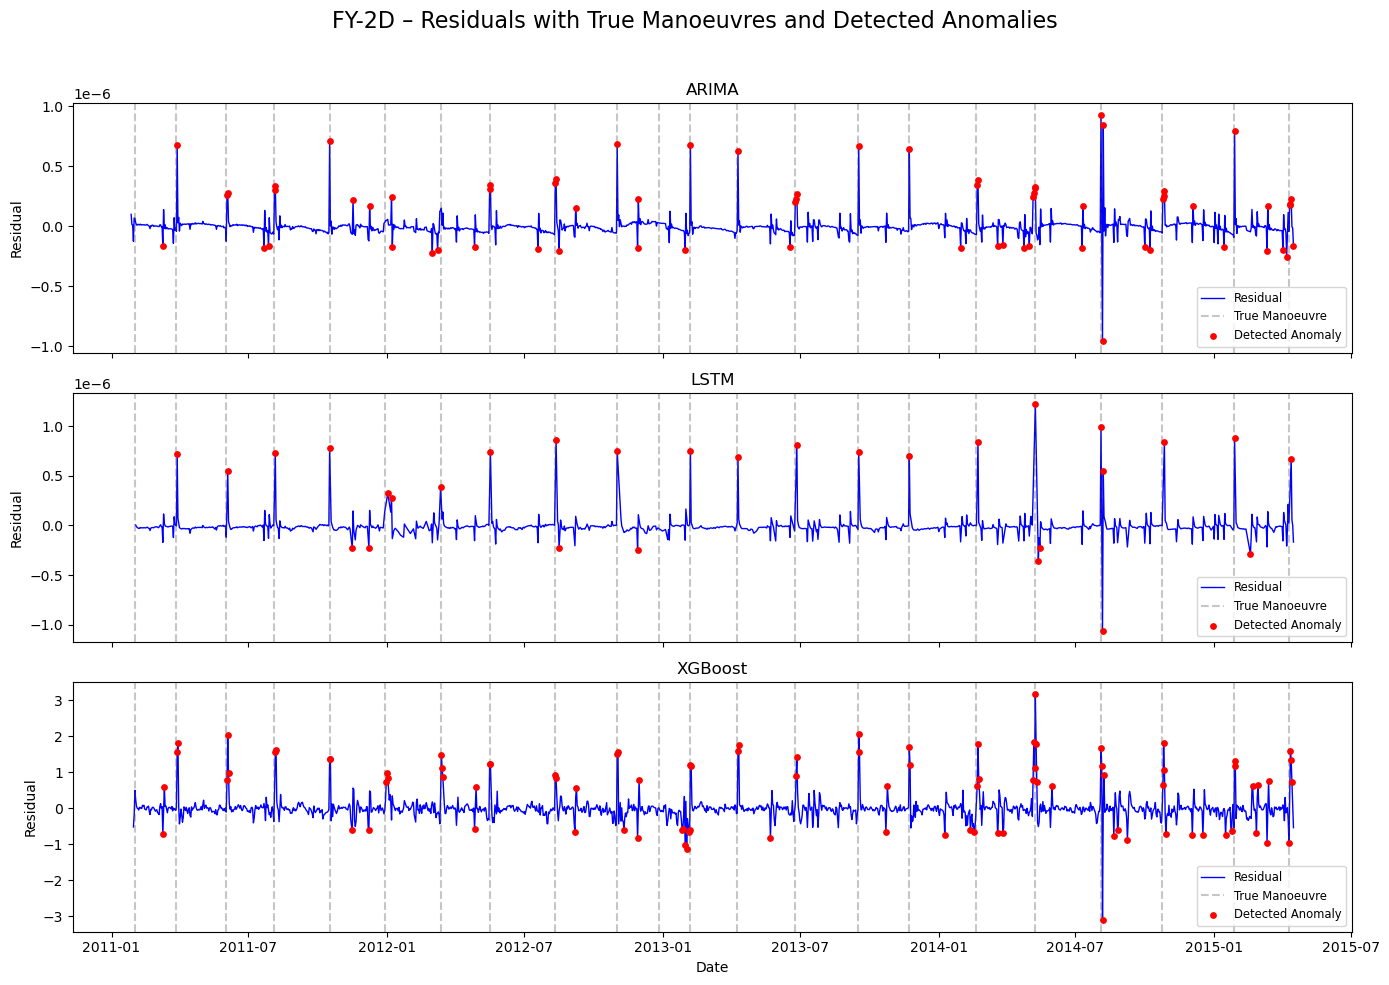

In [ ]:
# FY-2D
plot_residuals_with_manoeuvres_and_anomalies_final(
    sat_name="FY-2D",
    models_dict=fy2d_models,
    maneuver_df=maneuvers["FY2D"],
    k=3
)

In [139]:
# Load orbital data from uploaded .pkl
with open("orbitals.pkl", "rb") as f:
    orbitals = pickle.load(f)

# Show available satellite files and preview one
orbital_keys = list(orbitals.keys())
example_df = orbitals[orbital_keys[0]].head()

orbital_keys, example_df

(['CryoSat-2.csv',
  'Fengyun-2D.csv',
  'Fengyun-2E.csv',
  'Fengyun-2F.csv',
  'Fengyun-2H.csv',
  'Fengyun-4A.csv',
  'Haiyang-2A.csv',
  'Jason-1.csv',
  'Jason-2.csv',
  'Jason-3.csv',
  'SARAL.csv',
  'Sentinel-3A.csv',
  'Sentinel-3B.csv',
  'Sentinel-6A.csv',
  'TOPEX.csv'],
                      eccentricity  argument of perigee  inclination  \
 day_time                                                              
 2010-04-25 12:13:00      0.001190             3.773156     1.606104   
 2010-04-26 13:01:00      0.001207             3.697660     1.606110   
 2010-04-27 22:06:00      0.001224             3.603564     1.606097   
 2010-04-28 12:59:00      0.001233             3.566036     1.606094   
 2010-04-29 00:34:00      0.001252             3.529150     1.606097   
 
                      mean anomaly  Brouwer mean motion  right ascension  
 day_time                                                                 
 2010-04-25 12:13:00     -3.772437             0.063403     

In [140]:
import matplotlib.pyplot as plt

# Function to plot time series of all orbital parameters
def plot_orbital_time_series(df, sat_name):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    fig, axes = plt.subplots(df.shape[1], 1, figsize=(14, 2.5 * df.shape[1]), sharex=True)
    fig.suptitle(f"{sat_name} – Orbital Parameters Over Time", fontsize=16)

    for ax, col in zip(axes, df.columns):
        ax.plot(df.index, df[col], label=col, linewidth=1.2)
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.5)  # Add grid to each subplot

    axes[-1].set_xlabel("Date")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

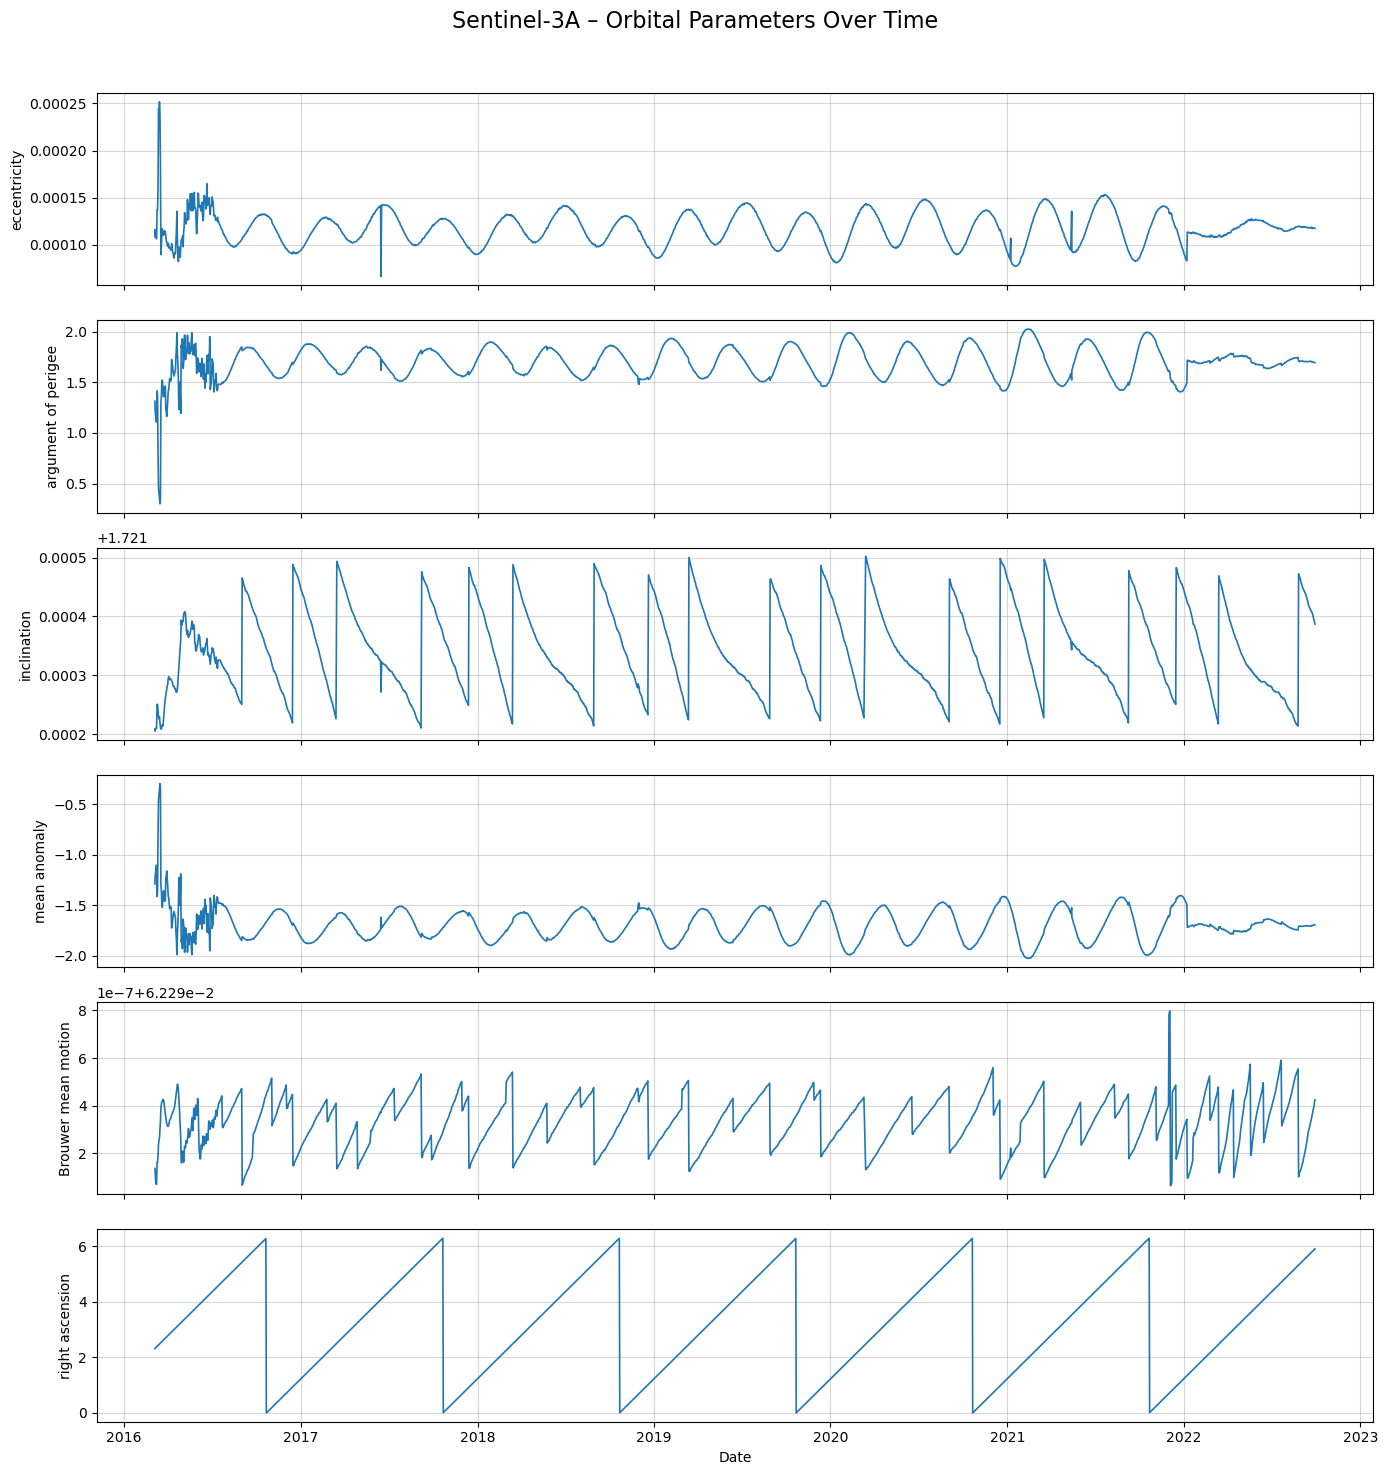

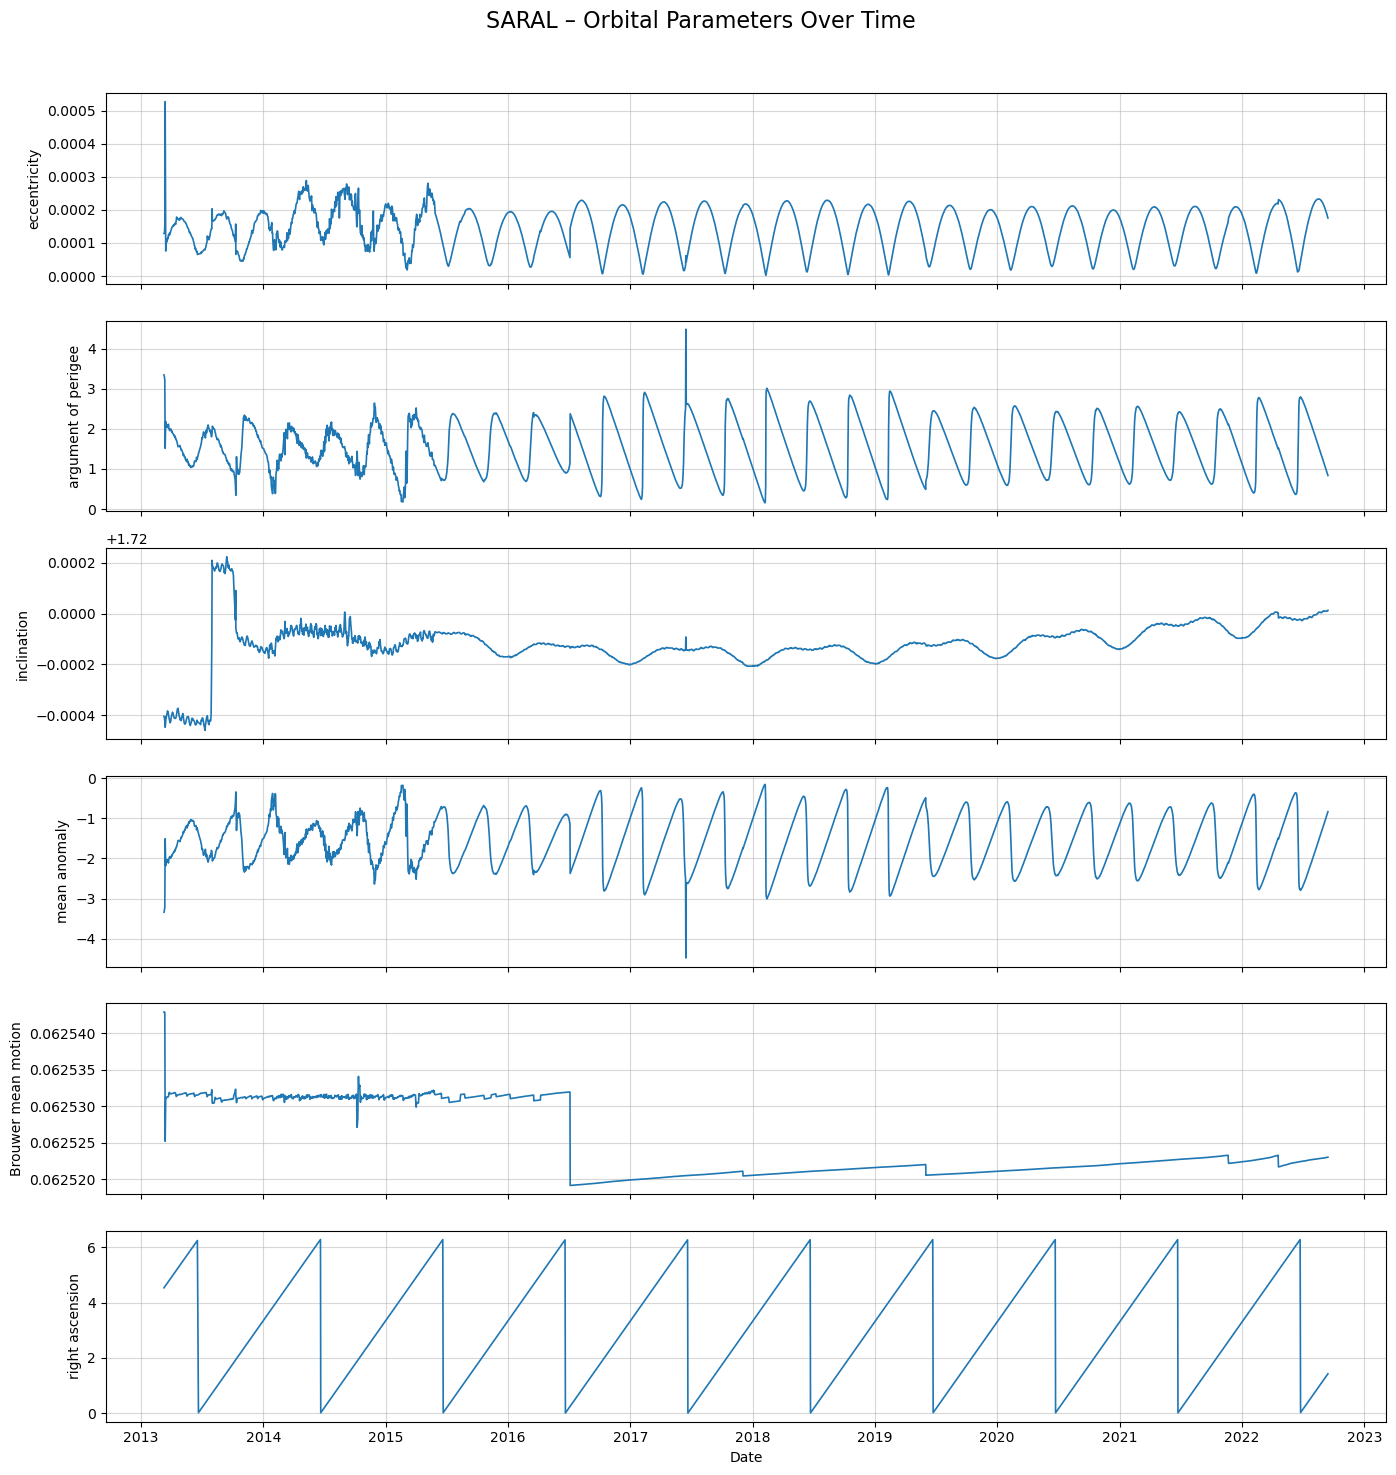

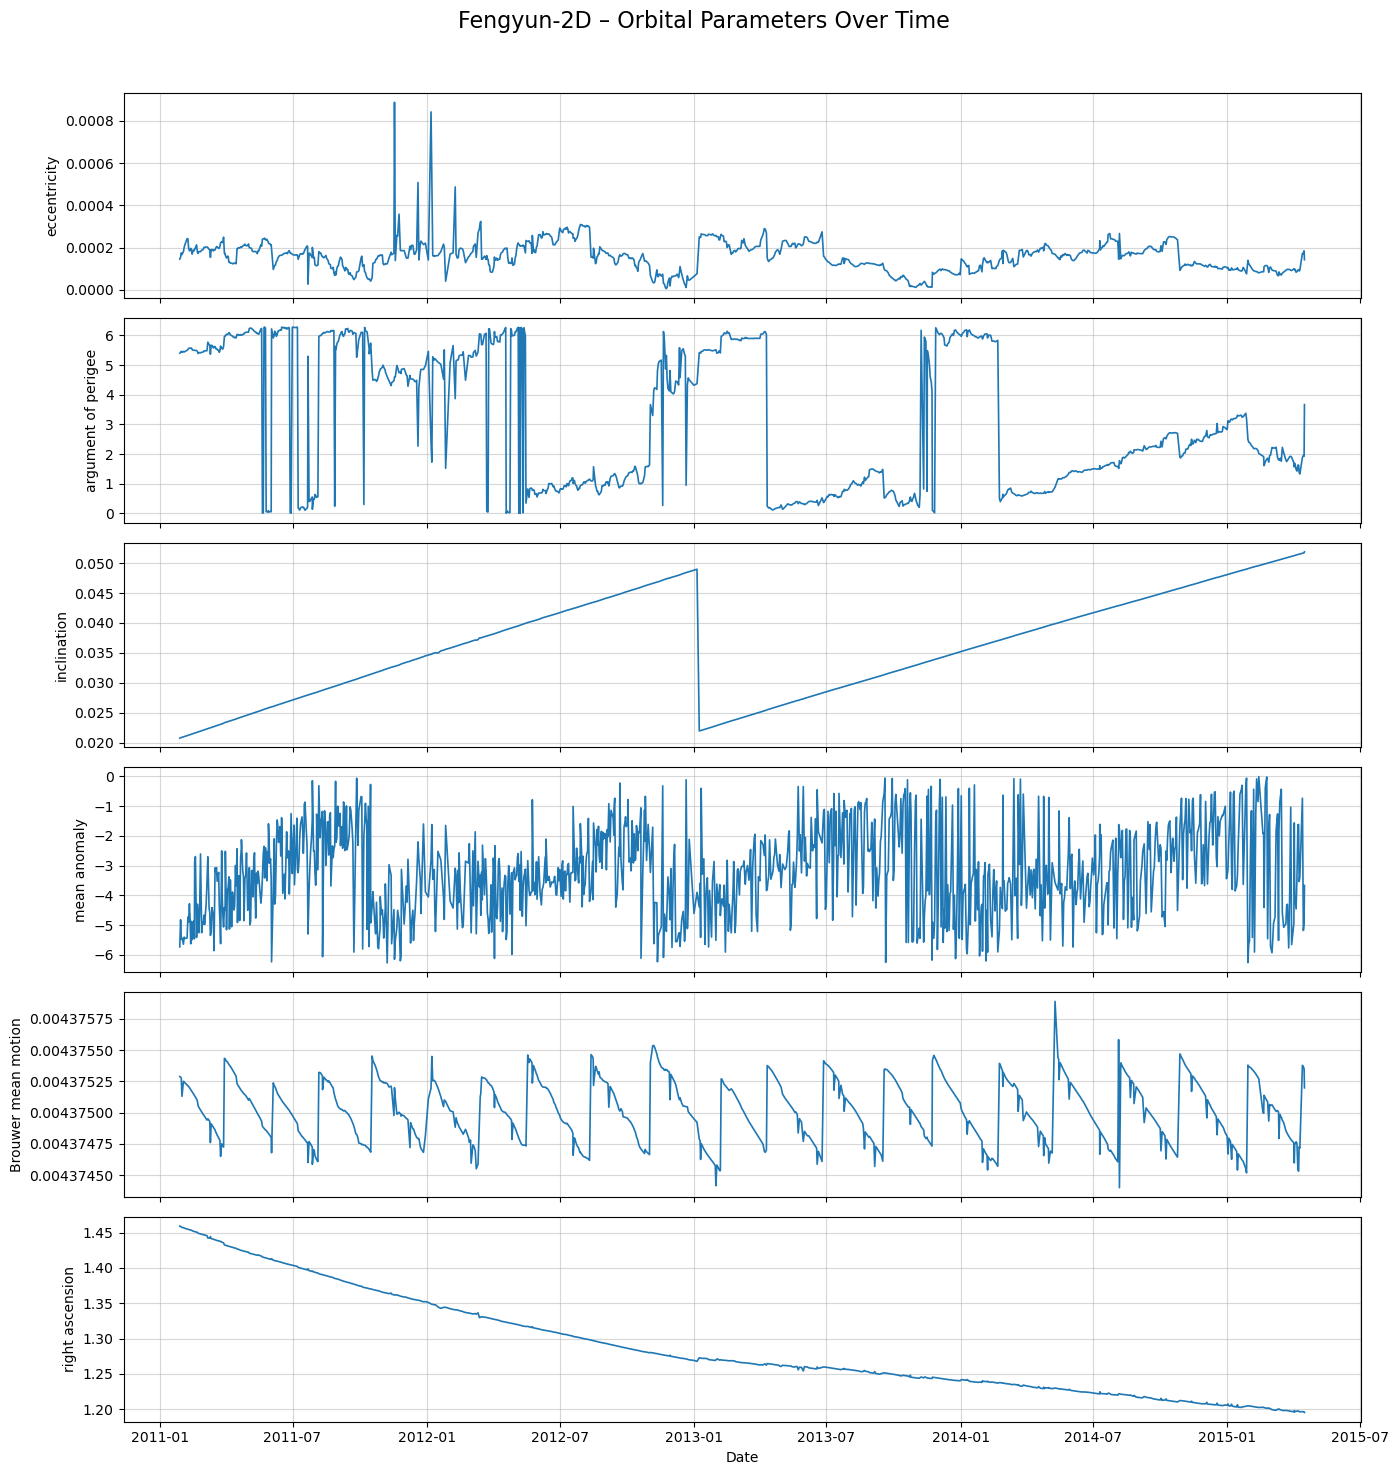

In [141]:
# Plot for Sentinel-3A
plot_orbital_time_series(orbitals["Sentinel-3A.csv"], "Sentinel-3A")

# Plot for SARAL
plot_orbital_time_series(orbitals["SARAL.csv"], "SARAL")

# Plot for Fengyun-2D
plot_orbital_time_series(orbitals["Fengyun-2D.csv"], "Fengyun-2D")

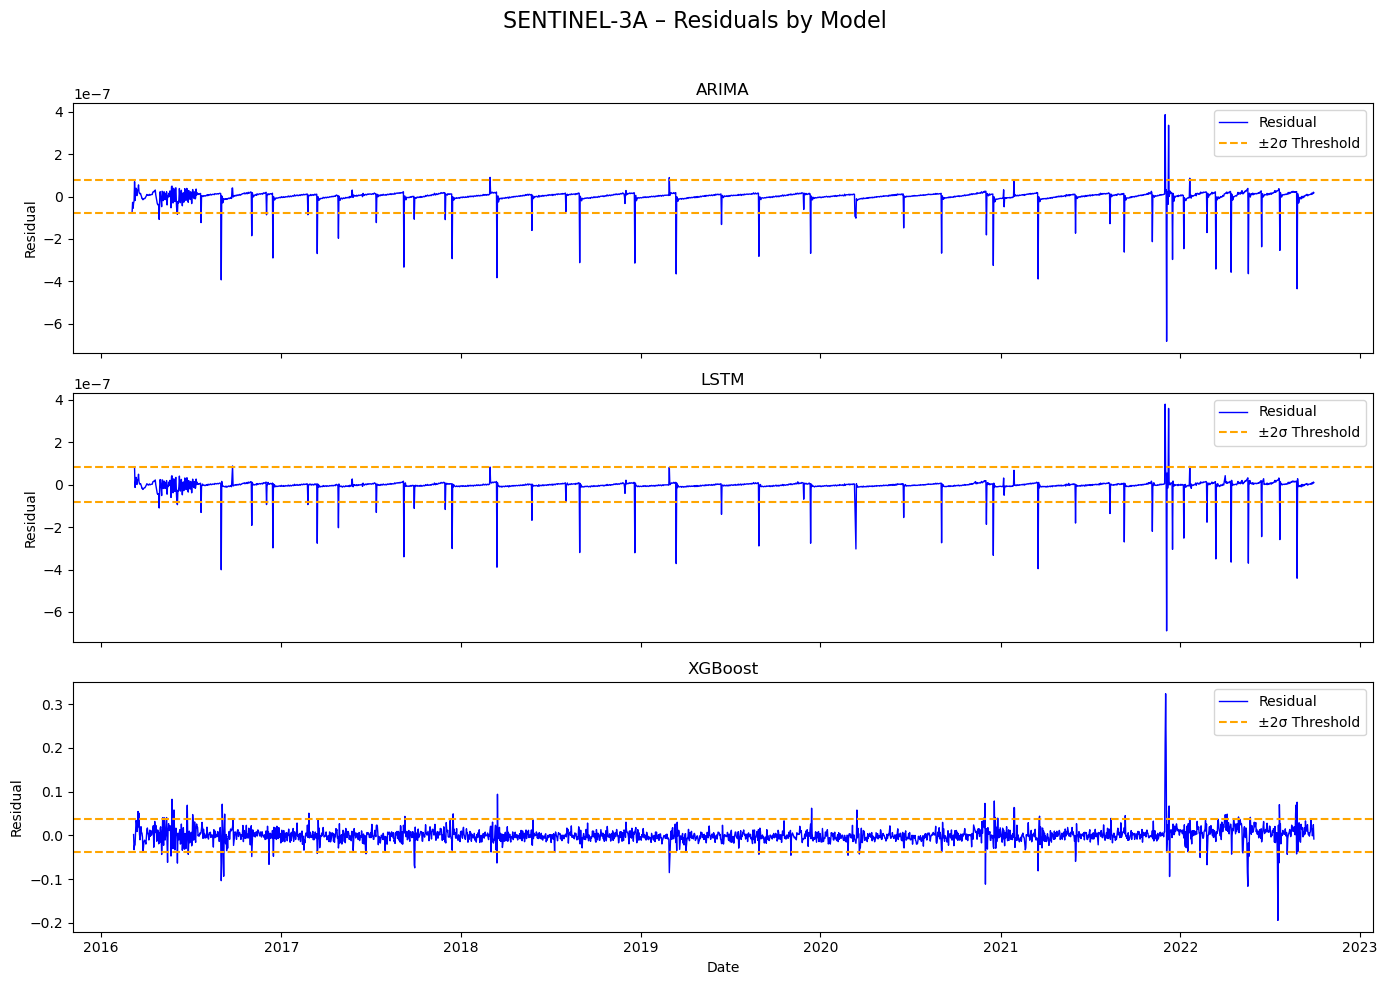

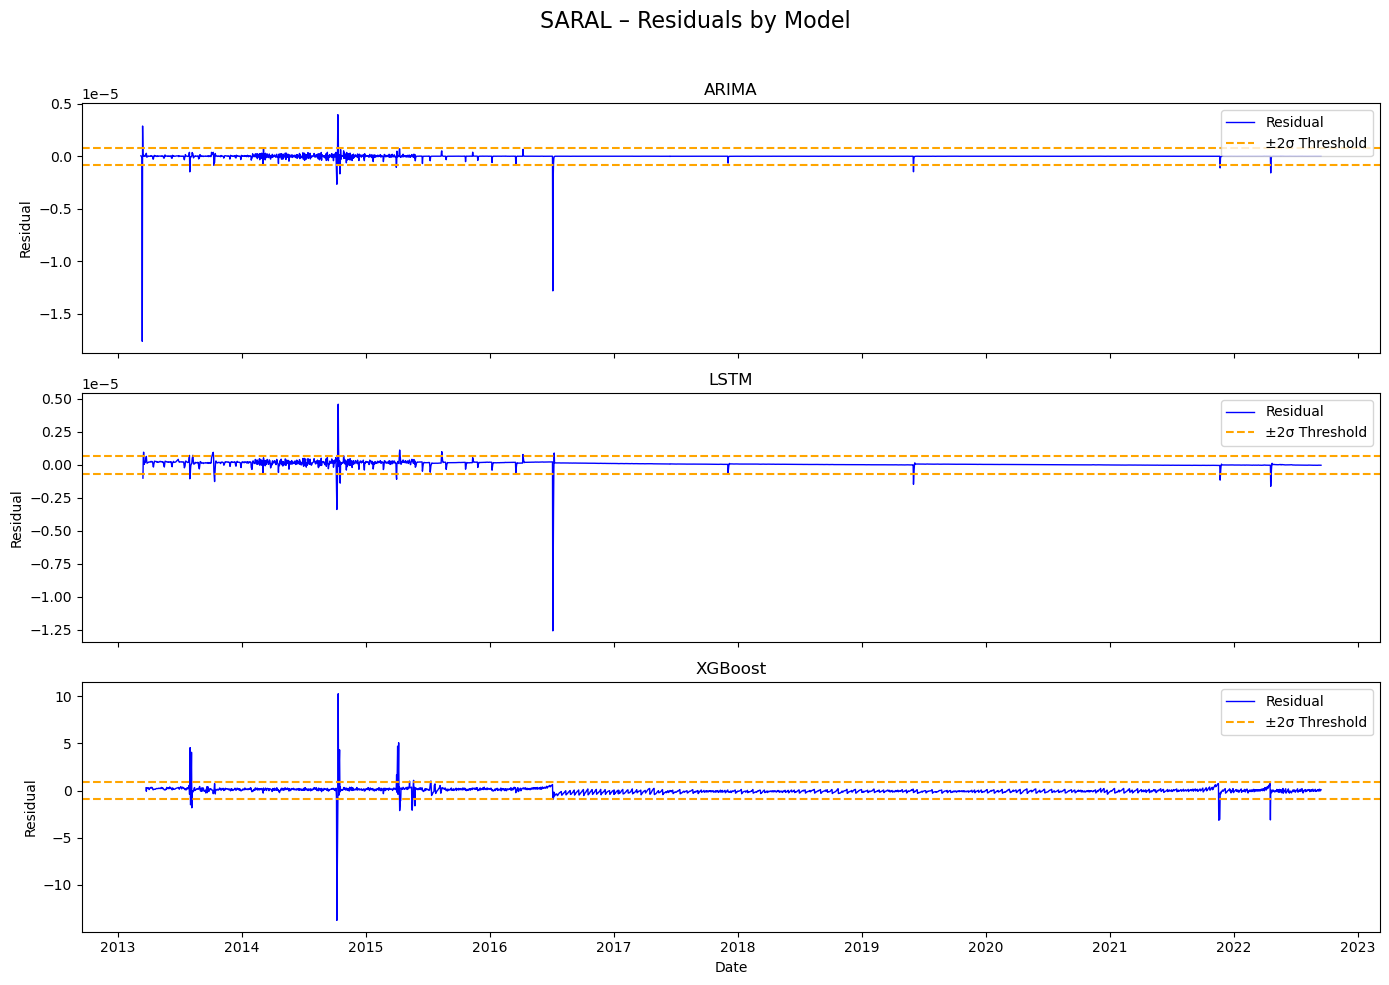

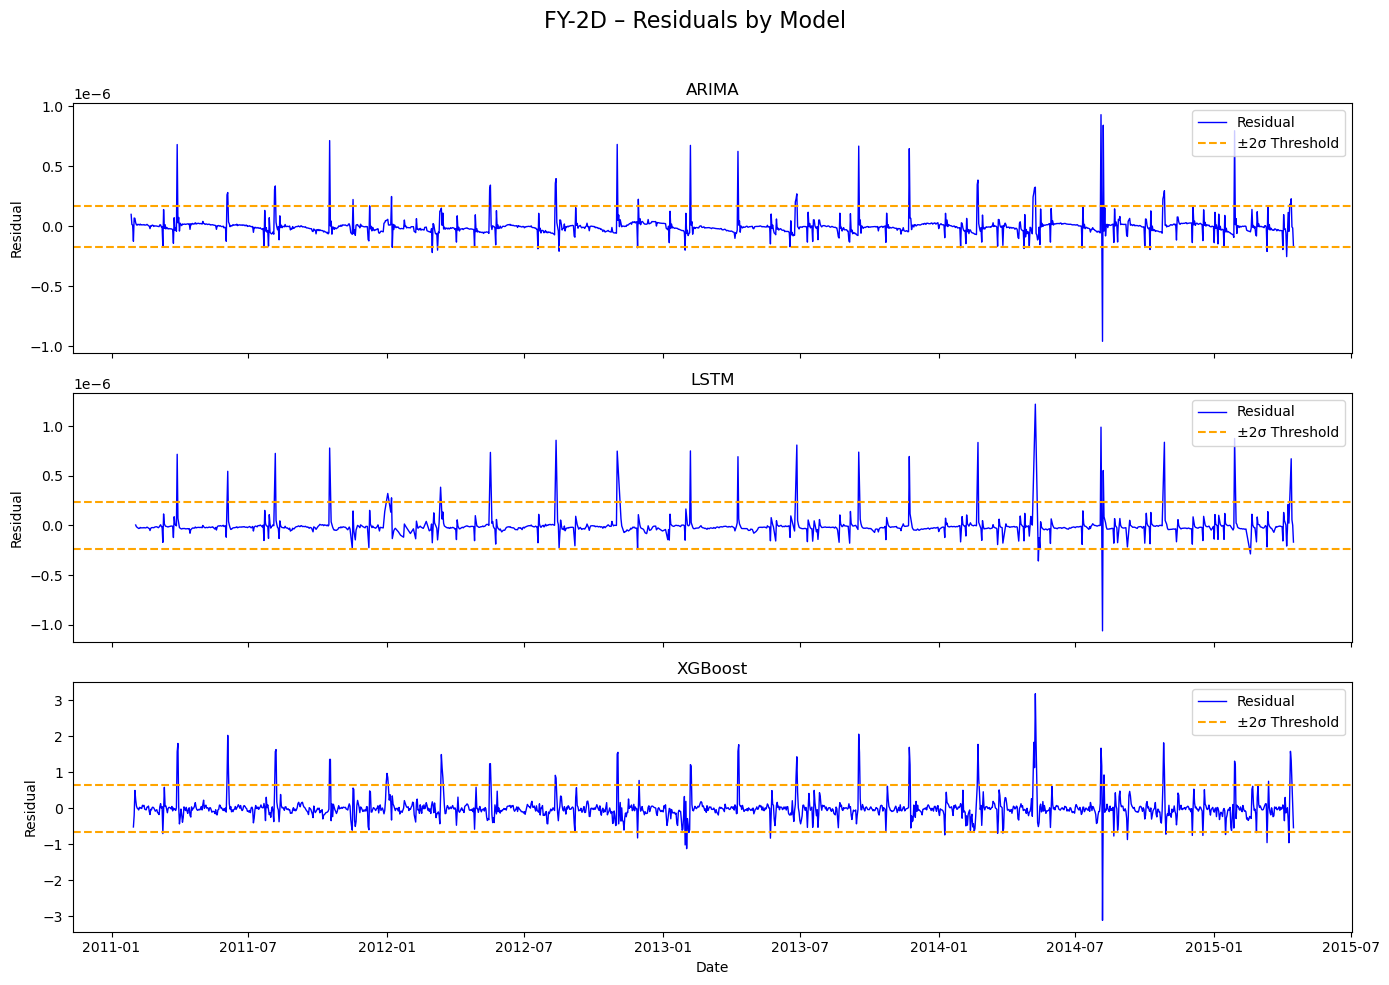

In [145]:
# Plotting function
def plot_residuals_thresholds_by_model(sat_name, models_dict, k=2):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{sat_name.upper()} – Residuals by Model", fontsize=16)

    for ax, (model_name, df) in zip(axes, models_dict.items()):
        df = df.sort_values("date")
        threshold = k * np.std(df["residual"])
        ax.plot(df["date"], df["residual"], label="Residual", color='blue', linewidth=1)
        ax.axhline(threshold, color="orange", linestyle="--", label=f"±{k}σ Threshold")
        ax.axhline(-threshold, color="orange", linestyle="--")
        ax.set_ylabel("Residual")
        ax.set_title(model_name)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Date")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Run for Sentinel-3A
plot_residuals_thresholds_by_model("Sentinel-3A", s3a_models, k=2)
plot_residuals_thresholds_by_model("SARAL", saral_models, k=2)
plot_residuals_thresholds_by_model("FY-2D", fy2d_models, k=2)